# Funções auxiliares

In [119]:
import numpy as np
from IPython.display import Markdown, display

def poly_to_latex(coeffs, var='s'):
    """
    Converte um array de coeficientes de polinômio numpy para uma string LaTeX.
    Ex: [1, 2, 1] -> 's^2 + 2s + 1'
    """
    if not coeffs.any(): # Handle all-zero polynomial
        return "0"

    latex_parts = []
    degree = len(coeffs) - 1

    for i, coeff in enumerate(coeffs):
        if coeff == 0:
            continue

        term = ""
        # Sign handling
        if coeff > 0 and latex_parts: # Add '+' if not the first term and positive
            term += "+"
        elif coeff < 0: # Add '-' if negative
            term += "-"
        coeff = abs(coeff)

        # Coefficient part
        if coeff != 1 or (degree - i) == 0: # Print coefficient if not 1 or if it's a constant term
            term += str(int(coeff))

        # Variable part
        if (degree - i) > 0:
            term += var
            if (degree - i) > 1:
                term += f"^{{{degree - i}}}"
        latex_parts.append(term)

    return "".join(latex_parts).replace("+-", "-").replace("++", "+") # Clean up double signs


# LGR numérico
Determinação do LGR numericametne para
comparação

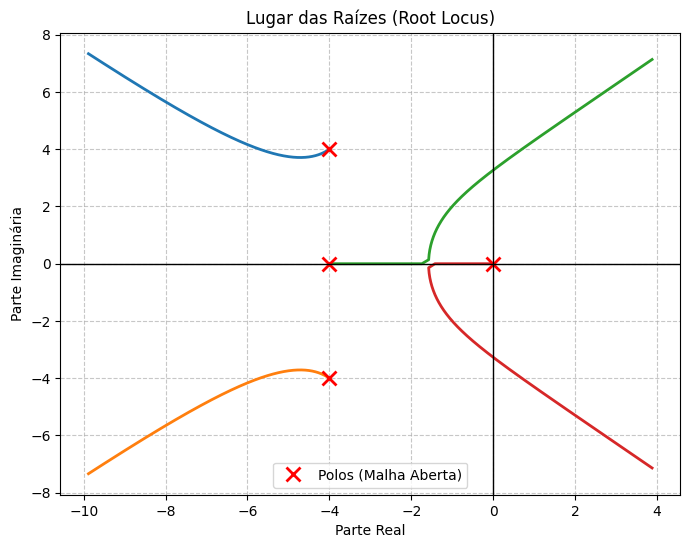

In [132]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Defina os coeficientes de G(s)H(s) = N(s)/D(s)
# Exemplo: G(s)H(s) = 1 / (s^3 + 8s^2 + 32s)
num = np.array([1])
den = np.array([1, 12, 64, 128, 0])

# 2. Crie um array de ganhos K
K_vals = np.linspace(0, 10000, 10000)

# Lista para armazenar todas as raízes calculadas
todas_raizes = []

# 3. Laço principal: calcula as raízes para cada valor de K
for K in K_vals:
    # Equação característica: D(s) + K*N(s) = 0
    eq_caracteristica = np.polyadd(den, K * num)

    # Calcula as raízes
    raizes = np.roots(eq_caracteristica)
    todas_raizes.append(raizes)

# Converte para array numpy
todas_raizes = np.array(todas_raizes)

# 4. Plotagem
plt.figure(figsize=(8, 6))

# Trajetória dos polos
for i in range(todas_raizes.shape[1]):
    plt.plot(np.real(todas_raizes[:, i]),
             np.imag(todas_raizes[:, i]),
             linewidth=2)

# Polos de malha aberta (K = 0)
polos_ma = np.roots(den)
plt.plot(np.real(polos_ma), np.imag(polos_ma),
         'x', markersize=10, color='red',
         markeredgewidth=2, label='Polos (Malha Aberta)')

# Zeros de malha aberta
zeros_ma = np.roots(num)
if len(zeros_ma) > 0:
    plt.plot(np.real(zeros_ma), np.imag(zeros_ma),
             'o', markersize=8, color='green',
             fillstyle='none', markeredgewidth=2,
             label='Zeros (Malha Aberta)')

# Eixos
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# Estética
plt.title('Lugar das Raízes (Root Locus)')
plt.xlabel('Parte Real')
plt.ylabel('Parte Imaginária')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.show()

# Algoritmo dos 12 passos

# Input

In [ ]:
import numpy as np
import sympy as sp
from IPython.display import Markdown

# Defina os coeficientes do numerador e denominador para G(s)
# Exemplo: G(s) = (s+1) / (s^3 + 6s^2 + 11s + 6) -> num = [1, 1], den = [1, 6, 11, 6]

# g_num = np.array([1, 1])
# g_den = np.array([1, 13, 0, 0])
# h_num = np.array([1])
# h_den = np.array([1])


g_num = np.array([1])
g_den = np.array([1,8,32,0])

h_num = np.array([1])
h_den = np.array([1,4])

# --- Cria a variável simbólica s ---
s = sp.symbols('s')

# Função auxiliar para converter array do numpy em polinômio do sympy
def array_to_sym(coeffs, var):
    return sum(c * var**i for i, c in enumerate(reversed(coeffs)))

# Passo 1

Escrever o polinômio característico do
modo que o parâmetro de interesse (K)
apareça claramente:

Queremos algo como 1 + kG(s)H(s) ou 1+KP(s)

In [ ]:
# 1. Converte os arrays para expressões simbólicas
G_num_s = array_to_sym(g_num, s)
G_den_s = array_to_sym(g_den, s)
H_num_s = array_to_sym(h_num, s)
H_den_s = array_to_sym(h_den, s)

# 2. Calcula G(s)H(s) de forma simbólica
# O SymPy já vai multiplicar e simplificar (cancelar s em cima e embaixo)
GH_expr = (G_num_s * H_num_s) / (G_den_s * H_den_s)

# 3. Extrai o NOVO numerador e denominador simplificados
# .as_numer_denom() separa a fração em dois termos
P_num_sym, P_den_sym = GH_expr.as_numer_denom()

# Expandir o denominador para que não fique fatorado na saída LaTeX
P_den_expanded_sym = sp.expand(P_den_sym)

# Reconstruir a expressão para o LaTeX com o denominador expandido
GH_expr_expanded_den = P_num_sym / P_den_expanded_sym

# # --- Exibição ---
# display(Markdown(f"O numerador $N(s)$ simplificado é: ${sp.latex(P_num_sym)}$"))
# display(Markdown(f"O denominador $D(s)$ simplificado é: ${sp.latex(P_den_sym)}$"))


# latex_eq = rf"${sp.latex(P_den_sym)} + K \cdot ({sp.latex(P_num_sym)}) = 0$"
# display(Markdown(f"O polinômio característico é: {latex_eq}"))
latex_final = rf"1 + G(s)H(s) = 1 + k{sp.latex(GH_expr_expanded_den)} = 1 + kP(s)"
display(Markdown(f"${latex_final}$"))

$1 + G(s)H(s) = 1 + k\frac{1}{s^{4} + 12 s^{3} + 64 s^{2} + 128 s} = 1 + kP(s)$

# Passo 2 : fatorar P(s) em polos e zeros

In [ ]:
# 3. Cálculo de G(s)H(s) com Simplificação
GH_expr = sp.simplify((G_num_s * H_num_s) / (G_den_s * H_den_s))
P_num_sym, P_den_sym = GH_expr.as_numer_denom()

# --- Função auxiliar para fatorar numericamente qualquer polinômio ---
def fatorar_numerico(polinomio, var):
    # nroots não funciona em constantes, então verificamos o grau
    if sp.degree(polinomio, var) < 1:
        return polinomio

    # Encontra raízes e cria os termos (s - r)
    roots = sp.nroots(polinomio)
    terms = [var - sp.N(r, 3, chop=True) for r in roots]

    # Extrai o coeficiente líder (ganho) para não perdê-lo na fatoração
    leading_coeff = sp.LC(polinomio, var)

    return leading_coeff * sp.Mul(*terms, evaluate=False)

# 4. Fatoração de ambos os termos
P_num_factored = fatorar_numerico(P_num_sym, s)
P_den_factored = fatorar_numerico(P_den_sym, s)

# 5. Montagem da Expressão Final
GH_final_display = P_num_factored / P_den_factored


display(Markdown(f"$P(s) = {sp.latex(GH_final_display)}$"))

$P(s) = \frac{1}{s \left(s + 4.0\right) \left(s + 4.0 - 4.0 i\right) \left(s + 4.0 + 4.0 i\right)}$

# Passo 4
Assinalar os segmentos do eixo real que são LGR
região a esquerda de números impares de polos ou zeros.
Assinalar também zeros com "O" e polos com "X"

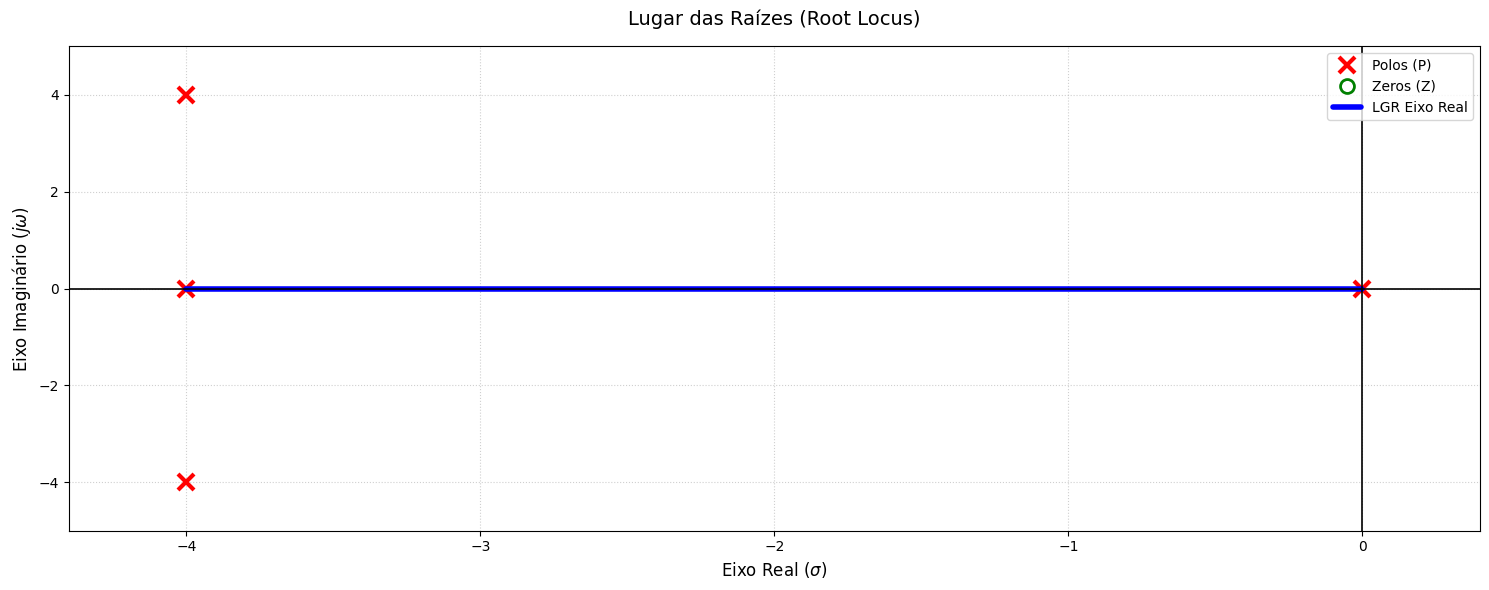

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# --- 1. Extração de Raízes Numericamente ---
# Zeros
# Check if the numerator is a constant (has no 's' variable)
if P_num_sym.is_number:
    all_zeros_sympy = []
else:
    all_zeros_sympy = sp.nroots(P_num_sym)
all_zeros = [complex(z) for z in all_zeros_sympy]
zeros_P_real = [z.real for z in all_zeros if abs(z.imag) < 1e-7]

# Polos
# Check if the denominator is a constant (unlikely in most control systems)
if P_den_sym.is_number:
    all_poles_sympy = []
else:
    all_poles_sympy = sp.nroots(P_den_sym)
all_poles = [complex(p) for p in all_poles_sympy]
poles_P_real = [p.real for p in all_poles if abs(p.imag) < 1e-7]

# Combine pontos para lógica do eixo real
all_real_points = sorted(list(set(zeros_P_real + poles_P_real)))

# --- 2. Configuração da Figura (Larga e elegante) ---
plt.figure(figsize=(15, 6)) # Proporção horizontal (L:15, A:6)
ax = plt.gca()

# --- 3. Plotagem de Polos e Zeros ---
plt.plot(np.real(all_poles), np.imag(all_poles), 'x',
         markersize=12, color='red', markeredgewidth=3, label='Polos (P)')
plt.plot(np.real(all_zeros), np.imag(all_zeros), 'o',
         markersize=10, color='green', fillstyle='none', markeredgewidth=2, label='Zeros (Z)')

# --- 4. Lógica do LGR no Eixo Real ---
rl_segments = []
if all_real_points:
    for i in range(len(all_real_points)):
        # Ponto de teste entre dois marcos ou à direita do último
        if i < len(all_real_points) - 1:
            test_point = (all_real_points[i] + all_real_points[i+1]) / 2
        else:
            test_point = all_real_points[i] + 0.5

        # Regra: Ímpar à direita (polos + zeros reais)
        count_right = sum(1 for p in poles_P_real if p > test_point) + \
                      sum(1 for z in zeros_P_real if z > test_point)

        if count_right % 2 != 0:
            start = all_real_points[i]
            # Se for o último ponto, estende para a esquerda (infinito)
            end = all_real_points[i+1] if i < len(all_real_points) - 1 else all_real_points[i] - 10
            rl_segments.append((start, end))

# Plotar os segmentos do eixo real
for i, (start, end) in enumerate(rl_segments):
    plt.plot([start, end], [0, 0], color='blue', linewidth=4,
             solid_capstyle='round', label='LGR Eixo Real' if i == 0 else "")

# --- 5. Estilização e Eixos ---
plt.axhline(0, color='black', linewidth=1.2) # Eixo Real
plt.axvline(0, color='black', linewidth=1.2) # Eixo Imaginário

# --- 6. AJUSTE DINÂMICO DE LIMITES (ENQUADRAMENTO JUSTO) ---
# Coletamos todas as coordenadas X relevantes (polos, zeros e segmentos do LGR)
all_x_coords = [p.real for p in all_poles] + [z.real for z in all_zeros]
for start, end in rl_segments:
    all_x_coords.extend([start, end])

if all_x_coords:
    x_min, x_max = min(all_x_coords), max(all_x_coords)

    # Calculamos a largura total (span) para criar um respiro (padding) proporcional
    x_span = x_max - x_min
    padding_x = x_span * 0.1 if x_span > 0 else 1.0  # 10% de margem

    # Se o gráfico estiver muito vazio à esquerda, limitamos o padding
    plt.xlim(x_min - padding_x, x_max + padding_x)

    # Ajuste do eixo Y (Simétrico para manter a estética de controle)
    y_coords = [abs(p.imag) for p in all_poles] + [abs(z.imag) for z in all_zeros]
    y_limit = max(y_coords) + 1 if y_coords else 2
    plt.ylim(-y_limit, y_limit)

# Força o gráfico a usar o espaço horizontal do figsize sem travar o aspecto
ax.set_aspect('auto')

plt.title('Lugar das Raízes (Root Locus)', fontsize=14, pad=15)
plt.xlabel(r'Eixo Real ($\sigma$)', fontsize=12)
plt.ylabel(r'Eixo Imaginário ($j\omega$)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Passo 5 : Determinar o numero de lugares separados
LS = max {Np, Nz}

In [127]:
import sympy as sp
from IPython.display import Markdown, display

# P_num_sym and P_den_sym are available from previous cells

# Determinar o número de polos (Np)
# sp.nroots retorna as raízes numéricas de um polinômio
# Usamos .free_symbols para verificar se a expressão é constante (não tem 's')
if not P_den_sym.free_symbols:
    Np = 0 # Não há polos se o denominador é uma constante
else:
    Np = len(sp.nroots(P_den_sym))

# Determinar o número de zeros (Nz)
# Usamos .free_symbols para verificar se a expressão é constante (não tem 's')
if not P_num_sym.free_symbols:
    Nz = 0 # Não há zeros se o numerador é uma constante
else:
    Nz = len(sp.nroots(P_num_sym))

# O número de lugares separados (Ls) é o máximo entre Np e Nz
Ls = max(Np, Nz)

display(Markdown(rf"O número de polos $N_p$ é: **{Np}**"))
display(Markdown(rf"O número de zeros $N_z$ é: **{Nz}**"))
display(Markdown(rf"O número de lugares separados $L_s = \max\{{N_p, N_z\}}$ é: **{Ls}**"))

O número de polos $N_p$ é: **4**

O número de zeros $N_z$ é: **0**

O número de lugares separados $L_s = \max\{N_p, N_z\}$ é: **4**

# Passo 6 Simetria
LGR é simétrico no eixo real
Devemos garantir isso quando formos desenhar
futuramente

# Passo 7 Assintotas e ângulos
## Centro das assintotas e angulos

(nP - nZ) seguimentos de um LGR
prosseguem em direção aos zeros
infinitos ao longo de assíntotas
centralizadas em σA e com ângulos φ

### Passo 7: Centro das assíntotas e ângulos

**Fórmula do Centroide:** $\sigma_A = \frac{\sum (-p_j) - \sum (-z_i)}{n_p - n_z}$

$\sigma_A = \frac{(-12.00) - (0.00)}{4} = -3.00$

**Fórmula dos Ângulos:** $\phi_A = \frac{(2q + 1)}{n_p - n_z} 180^\circ$

Para $q = 0$: $\phi_A = 45.0^\circ$

Para $q = 1$: $\phi_A = 135.0^\circ$

Para $q = 2$: $\phi_A = 225.0^\circ$

Para $q = 3$: $\phi_A = 315.0^\circ$

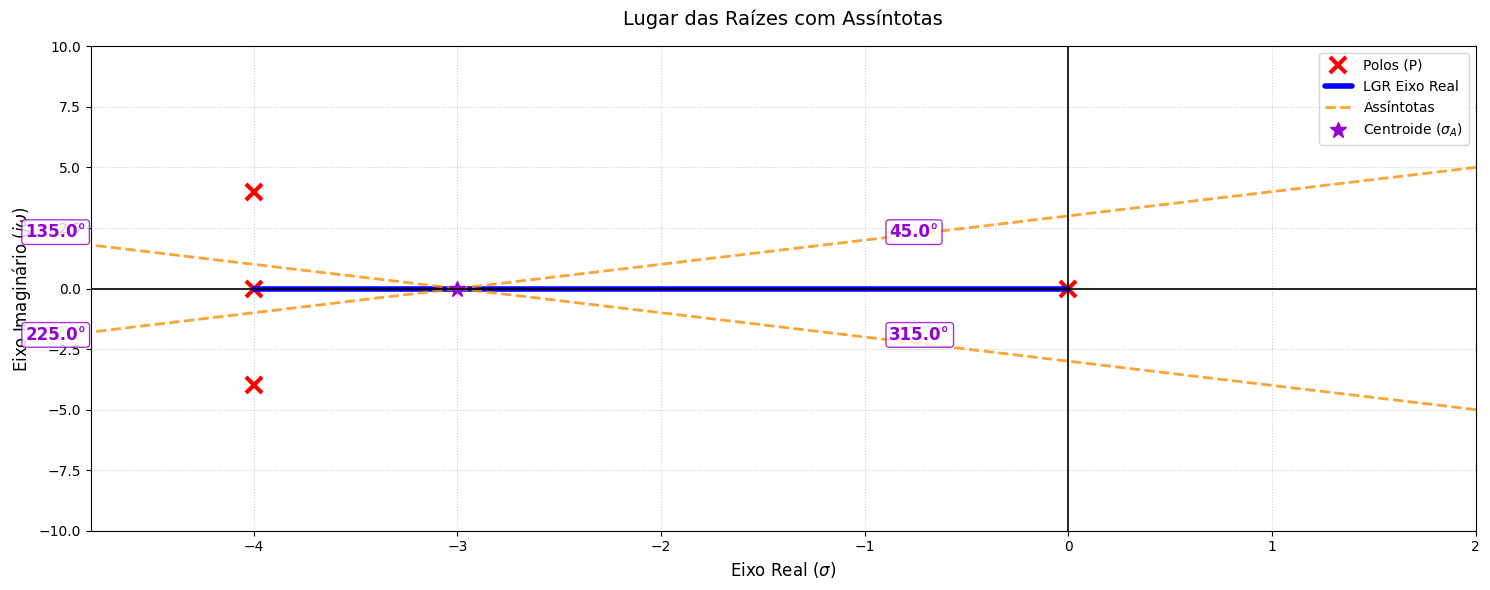

In [128]:
# Célula 5: Passo 7 - Assíntotas (Atualizada)
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# O número de assíntotas (Na) é a diferença entre polos e zeros
Na = Np - Nz

if Na > 0:
    # 1. Cálculo do Centroide (sigma_A)
    # A fórmula sum(-pj) e sum(-zi) equivale à soma direta dos valores das raízes.
    sum_poles = sum(np.real(all_poles))
    sum_zeros = sum(np.real(all_zeros)) if Nz > 0 else 0

    sigma_A = (sum_poles - sum_zeros) / Na

    # 2. Cálculo dos Ângulos das Assíntotas (phi_A)
    angles_deg = [((2 * q + 1) * 180) / Na for q in range(Na)]
    angles_rad = np.deg2rad(angles_deg)

    # --- Exibição dos Cálculos (Baseado na fórmula exata) ---
    display(Markdown("### Passo 7: Centro das assíntotas e ângulos"))
    display(Markdown(rf"**Fórmula do Centroide:** $\sigma_A = \frac{{\sum (-p_j) - \sum (-z_i)}}{{n_p - n_z}}$"))
    display(Markdown(rf"$\sigma_A = \frac{{({sum_poles:.2f}) - ({sum_zeros:.2f})}}{{{Na}}} = {sigma_A:.2f}$"))

    display(Markdown(rf"**Fórmula dos Ângulos:** $\phi_A = \frac{{(2q + 1)}}{{n_p - n_z}} 180^\circ$"))
    for q, ang in enumerate(angles_deg):
        display(Markdown(rf"Para $q = {q}$: $\phi_A = {ang:.1f}^\circ$"))

    # --- 3. Plotagem do Gráfico ---
    plt.figure(figsize=(15, 6))
    ax = plt.gca()

    # Re-plotar Polos, Zeros e LGR no Eixo Real
    plt.plot(np.real(all_poles), np.imag(all_poles), 'x', markersize=12, color='red', markeredgewidth=3, label='Polos (P)')
    if all_zeros:
        plt.plot(np.real(all_zeros), np.imag(all_zeros), 'o', markersize=10, color='green', fillstyle='none', markeredgewidth=2, label='Zeros (Z)')

    for i, (start, end) in enumerate(rl_segments):
        plt.plot([start, end], [0, 0], color='blue', linewidth=4, solid_capstyle='round', label='LGR Eixo Real' if i == 0 else "")

    # Plotar as Assíntotas
    line_length = 30
    for i, angle in enumerate(angles_rad):
        dx = line_length * np.cos(angle)
        dy = line_length * np.sin(angle)

        plt.plot([sigma_A, sigma_A + dx], [0, dy], '--', color='darkorange', alpha=0.8, linewidth=2, label='Assíntotas' if i == 0 else "")

        # Anotação do ângulo
        text_r = 3
        text_x = sigma_A + text_r * np.cos(angle)
        text_y = text_r * np.sin(angle)

        if abs(text_y) < 0.5: text_y += 0.8 * np.sign(text_y + 0.01)

        plt.text(text_x, text_y, f'{angles_deg[i]:.1f}°', color='darkviolet', fontsize=12, fontweight='bold',
                 bbox=dict(facecolor='white', edgecolor='darkviolet', boxstyle='round,pad=0.2', alpha=0.8))

    # Marcar o Centroide
    plt.plot(sigma_A, 0, '*', markersize=12, color='darkviolet', label=r'Centroide ($\sigma_A$)')

    # Estilização
    plt.axhline(0, color='black', linewidth=1.2)
    plt.axvline(0, color='black', linewidth=1.2)

    # Enquadramento
    all_x_coords = [p.real for p in all_poles] + [z.real for z in all_zeros] + [sigma_A]
    for start, end in rl_segments:
        all_x_coords.extend([start, end])

    if all_x_coords:
        x_min, x_max = min(all_x_coords), max(all_x_coords)
        x_span = x_max - x_min
        padding_x = x_span * 0.2 if x_span > 0 else 3.0
        plt.xlim(x_min - padding_x, max(x_max + padding_x, 2))

        y_coords = [abs(p.imag) for p in all_poles] + [abs(z.imag) for z in all_zeros]
        y_limit = max(y_coords) + 6 if y_coords else 6
        plt.ylim(-y_limit, y_limit)

    ax.set_aspect('auto')
    plt.title('Lugar das Raízes com Assíntotas', fontsize=14, pad=15)
    plt.xlabel(r'Eixo Real ($\sigma$)', fontsize=12)
    plt.ylabel(r'Eixo Imaginário ($j\omega$)', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

else:
    display(Markdown(r"**Não há assíntotas para o infinito.** O número de polos não é maior que o número de zeros ($n_p \le n_z$)."))

# Passo 8 pts in/out


### Passo 8: Pontos de Saída/Entrada no Eixo Real

**1º Fazer $K = p(s)$:**

A partir da equação característica, isolamos $K$:

$$K = p(s) = -\frac{1}{P(s)} = -\frac{D(s)}{N(s)} = - s \left(s + 4\right) \left(s^{2} + 8 s + 32\right)$$

**2º Determinar as raízes de $\frac{dp(s)}{ds} = 0$:**

...

$$\frac{dp(s)}{ds} = - 4 s^{3} - 36 s^{2} - 128 s - 128$$

Para a derivada ser zero, basta que o polinômio do numerador seja zero:

$$4 s^{3} + 36 s^{2} + 128 s + 128 = 0$$

**Todas as raízes calculadas:** $s = [-1.5767, -3.7117 + -2.5533j, -3.7117 + 2.5533j]$

**Raízes válidas (pertencem ao LGR no eixo real):** $s = -1.5767$

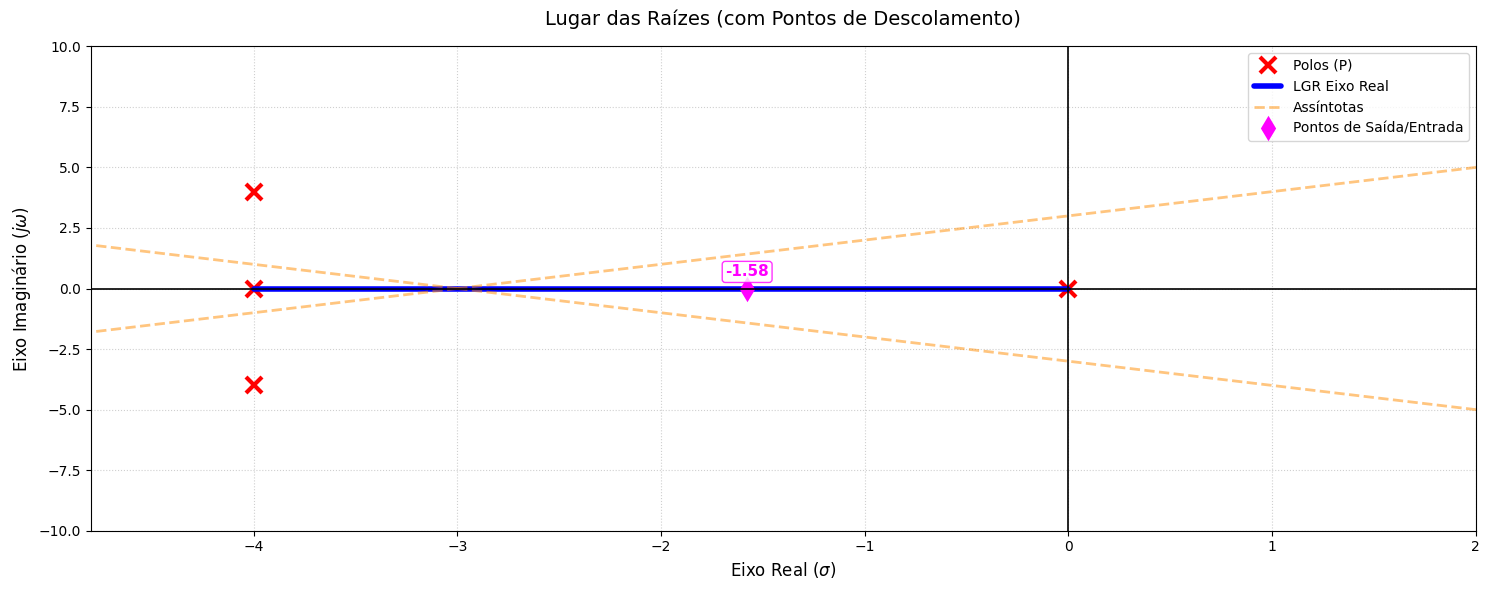

In [135]:
# Célula 6: Passo 8 - Pontos de Saída/Entrada (Descolamento)
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# 1. Obter os polinômios N(s) e D(s) das células anteriores
N_s = P_num_sym
D_s = P_den_sym

# 2. Definir a função K = p(s)
K_expr = -D_s / N_s

# 3. Calcular a derivada dK/ds simbolicamente
dK_ds = sp.diff(K_expr, s)

# Simplifica a derivada para exibição (junta numa única fração)
dK_ds_simplified = sp.cancel(dK_ds)

# 4. Achar as raízes: igualar o numerador da derivada a zero (D'(s)N(s) - D(s)N'(s) = 0)
dN_ds = sp.diff(N_s, s)
dD_ds = sp.diff(D_s, s)
break_eq = dD_ds * N_s - D_s * dN_ds

# 5. Calcular as raízes numéricas
break_roots_sympy = sp.nroots(break_eq)
break_roots_complex = [complex(r) for r in break_roots_sympy]

# 6. Filtrar os pontos válidos (reais E pertencentes ao LGR no eixo real)
valid_break_points = []
tol = 1e-5

for r in break_roots_complex:
    if abs(r.imag) < tol:
        real_val = r.real
        is_on_lgr = False

        for start, end in rl_segments:
            seg_min, seg_max = min(start, end), max(start, end)
            if seg_min - tol <= real_val <= seg_max + tol:
                is_on_lgr = True
                break

        if is_on_lgr:
            valid_break_points.append(real_val)

valid_break_points = sorted(list(set([round(p, 4) for p in valid_break_points])))

# Formatar todas as raízes para exibição
all_roots_str = ", ".join([f"{r.real:.4f} + {r.imag:.4f}j" if abs(r.imag) > tol else f"{r.real:.4f}" for r in break_roots_complex])

# --- Exibição dos Cálculos Matemáticos ---
display(Markdown("### Passo 8: Pontos de Saída/Entrada no Eixo Real"))

display(Markdown(r"**1º Fazer $K = p(s)$:**"))
display(Markdown(rf"A partir da equação característica, isolamos $K$:"))
display(Markdown(rf"$$K = p(s) = -\frac{{1}}{{P(s)}} = -\frac{{D(s)}}{{N(s)}} = {sp.latex(K_expr)}$$"))

display(Markdown(r"**2º Determinar as raízes de $\frac{dp(s)}{ds} = 0$:**"))
display(Markdown(rf"Calculando a derivada:"))
display(Markdown(rf"$$\frac{{dp(s)}}{{ds}} = {sp.latex(dK_ds_simplified)}$$"))

display(Markdown(rf"Para a derivada ser zero, basta que o polinômio do numerador seja zero:"))
display(Markdown(rf"$${sp.latex(sp.expand(break_eq))} = 0$$"))

display(Markdown(rf"**Todas as raízes calculadas:** $s = [{all_roots_str}]$"))

if valid_break_points:
    points_str = ", ".join([str(p) for p in valid_break_points])
    display(Markdown(rf"**Raízes válidas (pertencem ao LGR no eixo real):** $s = {points_str}$"))
else:
    display(Markdown("**Não há raízes válidas no eixo real para este sistema.**"))

# --- Plotagem ---
plt.figure(figsize=(15, 6))
ax = plt.gca()

# Re-plotar Polos, Zeros e LGR
plt.plot(np.real(all_poles), np.imag(all_poles), 'x', markersize=12, color='red', markeredgewidth=3, label='Polos (P)')
if all_zeros:
    plt.plot(np.real(all_zeros), np.imag(all_zeros), 'o', markersize=10, color='green', fillstyle='none', markeredgewidth=2, label='Zeros (Z)')

for i, (start, end) in enumerate(rl_segments):
    plt.plot([start, end], [0, 0], color='blue', linewidth=4, solid_capstyle='round', label='LGR Eixo Real' if i == 0 else "")

# Assíntotas
if Na > 0:
    line_length = 30
    for i, angle in enumerate(angles_rad):
        dx = line_length * np.cos(angle)
        dy = line_length * np.sin(angle)
        plt.plot([sigma_A, sigma_A + dx], [0, dy], '--', color='darkorange', alpha=0.5, linewidth=2, label='Assíntotas' if i == 0 else "")

# Destacar os Pontos de Descolamento
if valid_break_points:
    plt.plot(valid_break_points, [0]*len(valid_break_points), 'd', markersize=10, color='magenta', markeredgewidth=2, label='Pontos de Saída/Entrada')
    for p in valid_break_points:
        # Posição do texto ajustada para não embolar com o eixo
        plt.text(p, 0.5, f'{p:.2f}', color='magenta', fontsize=11, fontweight='bold', ha='center',
                 bbox=dict(facecolor='white', edgecolor='magenta', boxstyle='round,pad=0.2', alpha=0.8))

# Estilização
plt.axhline(0, color='black', linewidth=1.2)
plt.axvline(0, color='black', linewidth=1.2)

# Enquadramento Dinâmico
all_x_coords = [p.real for p in all_poles] + [z.real for z in all_zeros]
if Na > 0: all_x_coords.append(sigma_A)
all_x_coords.extend(valid_break_points)
for start, end in rl_segments:
    all_x_coords.extend([start, end])

if all_x_coords:
    x_min, x_max = min(all_x_coords), max(all_x_coords)
    x_span = x_max - x_min
    padding_x = x_span * 0.2 if x_span > 0 else 3.0
    plt.xlim(x_min - padding_x, max(x_max + padding_x, 2))

    y_coords = [abs(p.imag) for p in all_poles] + [abs(z.imag) for z in all_zeros]
    y_limit = max(y_coords) + 6 if y_coords else 6
    plt.ylim(-y_limit, y_limit)

ax.set_aspect('auto')
plt.title('Lugar das Raízes (com Pontos de Descolamento)', fontsize=14, pad=15)
plt.xlabel(r'Eixo Real ($\sigma$)', fontsize=12)
plt.ylabel(r'Eixo Imaginário ($j\omega$)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Passo 9 (Cruz. Eixo Imag)

### Passo 9: Cruzamento com o Eixo Imaginário (Routh-Hurwitz)

**Equação Característica $1 + k \frac{N(s)}{D(s)} = 0 \implies D(s) + kN(s) = 0$:**

$k + s^{4} + 12 s^{3} + 64 s^{2} + 128 s = 0$

#### Tabela de Routh-Hurwitz Gerada:

| Linha | Coluna 1 | Coluna 2 | Coluna 3 |
|---|---|---|---|
| $s^4$ | $1$ | $64$ | $k$ |
| $s^3$ | $12$ | $128$ | $0$ |
| $s^2$ | $\frac{160}{3}$ | $k$ | $0$ |
| $s^1$ | $128 - \frac{9 k}{40}$ | $0$ | $0$ |
| $s^0$ | $k$ | $0$ | $0$ |


...

**Para encontrar a margem de estabilidade, forçamos o primeiro termo da linha $s^1$ a ser zero:**

$128 - \frac{9 k}{40} = 0$

**Para o ganho crítico $k = 568.8889$, a equação auxiliar (da linha $s^2$) é:**

$53.3333333333333 s^{2} + 568.888888888889 = 0$

**Pontos de cruzamento exatos no eixo imaginário:** $s = - 3.2660j, 3.2660j$

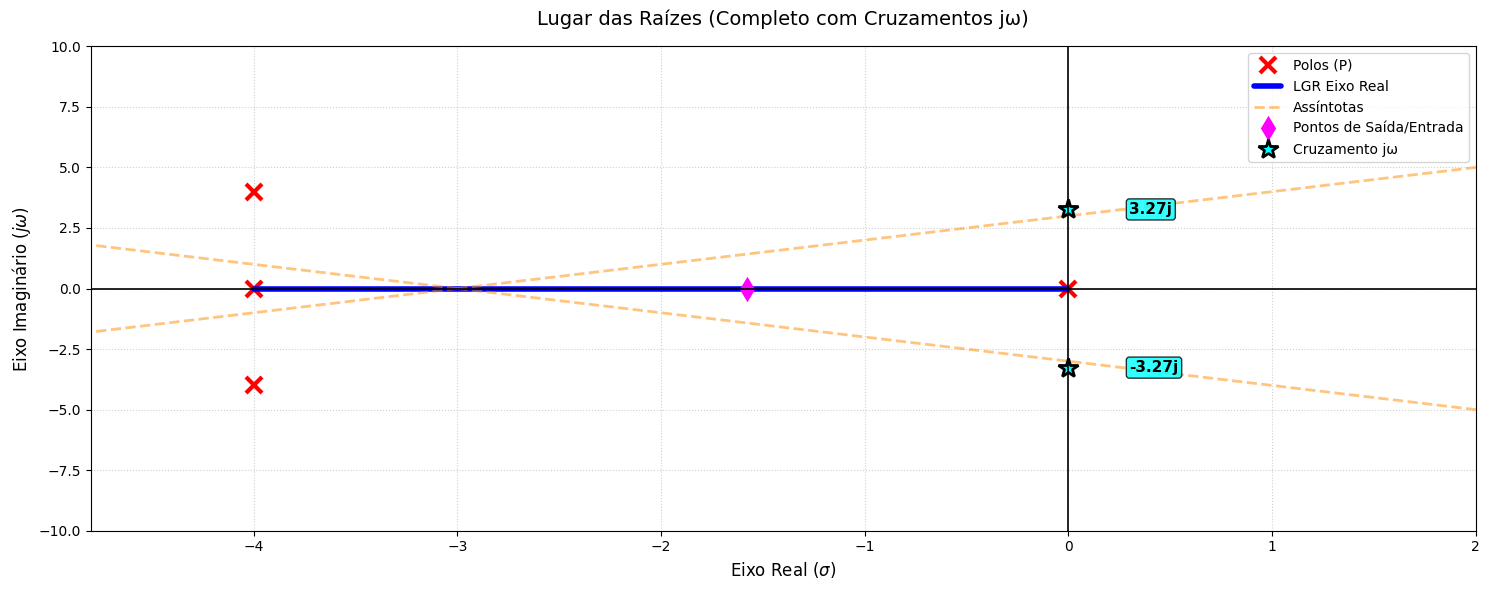

In [137]:
# Célula 7: Passo 9 - Cruzamento com o Eixo Imaginário (Routh-Hurwitz)
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# 1. Definir a variável simbólica k
k = sp.symbols('k', real=True)

# 2. Obter a Equação Característica: D(s) + k*N(s) = 0
CE_expr = sp.expand(P_den_sym + k * P_num_sym)
CE_poly = sp.Poly(CE_expr, s)
coeffs = CE_poly.all_coeffs()
n = CE_poly.degree()

display(Markdown("### Passo 9: Cruzamento com o Eixo Imaginário (Routh-Hurwitz)"))
display(Markdown(r"**Equação Característica $1 + k \frac{N(s)}{D(s)} = 0 \implies D(s) + kN(s) = 0$:**"))
display(Markdown(rf"${sp.latex(CE_expr)} = 0$"))

# 3. Construir a Tabela de Routh
routh_table = []
row0 = coeffs[0::2]
row1 = coeffs[1::2]

max_len = max(len(row0), len(row1))
row0.extend([0] * (max_len - len(row0)))
row1.extend([0] * (max_len - len(row1)))

routh_table.append(row0)
routh_table.append(row1)

for i in range(2, n + 1):
    prev_row = routh_table[i-1]
    pprev_row = routh_table[i-2]
    new_row = []

    for j in range(len(prev_row) - 1):
        elem = (prev_row[0] * pprev_row[j+1] - pprev_row[0] * prev_row[j+1]) / prev_row[0]
        new_row.append(sp.cancel(elem))

    new_row.append(0)
    routh_table.append(new_row)

# --- NOVA PARTE: Exibir a Tabela de Routh-Hurwitz ---
table_md = "| Linha | " + " | ".join([f"Coluna {i+1}" for i in range(max_len)]) + " |\n"
table_md += "|" + "---|" * (max_len + 1) + "\n"

for i, row in enumerate(routh_table):
    power = n - i
    row_str = f"| $s^{power}$ | "
    # Simplifica a visualização para não ficar gigante na tela
    row_str += " | ".join([f"${sp.latex(sp.cancel(elem))}$" if str(elem) != "0" else "$0$" for elem in row]) + " |\n"
    table_md += row_str

display(Markdown("#### Tabela de Routh-Hurwitz Gerada:"))
display(Markdown(table_md))
display(Markdown("---"))
# --------------------------------------------------

# 4. Procurar a condição de estabilidade marginal (linha s^1 zerada)
s1_elem = routh_table[n-1][0]

display(Markdown(r"**Para encontrar a margem de estabilidade, forçamos o primeiro termo da linha $s^1$ a ser zero:**"))
display(Markdown(rf"${sp.latex(sp.cancel(s1_elem))} = 0$"))

k_crits = []
crossing_points = []

if s1_elem.has(k):
    num, den = sp.fraction(sp.cancel(s1_elem))
    possible_ks = sp.solve(num, k)

    for pk in possible_ks:
        if pk.is_real and pk > 0:
            k_crits.append(float(pk))

# 5. Encontrar as raízes usando a Equação Auxiliar (linha s^2)
for kc in k_crits:
    aux_row = routh_table[n-2]

    A = aux_row[0].subs(k, kc)
    B = aux_row[1].subs(k, kc)
    aux_eq = sp.simplify(A * s**2 + B)

    display(Markdown(rf"**Para o ganho crítico $k = {kc:.4f}$, a equação auxiliar (da linha $s^2$) é:**"))
    display(Markdown(rf"${sp.latex(aux_eq)} = 0$"))

    roots_aux = sp.solve(aux_eq, s)
    for r in roots_aux:
        crossing_points.append(complex(r))

valid_crossings = sorted(list(set([complex(pt) for pt in crossing_points if abs(pt.real) < 1e-5])), key=lambda x: x.imag)

if valid_crossings:
    cross_str = ", ".join([f"{pt.imag:.4f}j" if pt.imag >= 0 else f"- {abs(pt.imag):.4f}j" for pt in valid_crossings])
    display(Markdown(rf"**Pontos de cruzamento exatos no eixo imaginário:** $s = {cross_str}$"))
else:
    display(Markdown("**O Lugar das Raízes não cruza o eixo imaginário para $k > 0$.**"))

# --- 6. Plotagem de Atualização ---
plt.figure(figsize=(15, 6))
ax = plt.gca()

# Re-plotar Polos, Zeros e LGR Eixo Real
plt.plot(np.real(all_poles), np.imag(all_poles), 'x', markersize=12, color='red', markeredgewidth=3, label='Polos (P)')
if all_zeros:
    plt.plot(np.real(all_zeros), np.imag(all_zeros), 'o', markersize=10, color='green', fillstyle='none', markeredgewidth=2, label='Zeros (Z)')

for i, (start, end) in enumerate(rl_segments):
    plt.plot([start, end], [0, 0], color='blue', linewidth=4, solid_capstyle='round', label='LGR Eixo Real' if i == 0 else "")

# Assíntotas
if Na > 0:
    line_length = 30
    for i, angle in enumerate(angles_rad):
        dx = line_length * np.cos(angle)
        dy = line_length * np.sin(angle)
        plt.plot([sigma_A, sigma_A + dx], [0, dy], '--', color='darkorange', alpha=0.5, linewidth=2, label='Assíntotas' if i == 0 else "")

# Pontos de Descolamento
if valid_break_points:
    plt.plot(valid_break_points, [0]*len(valid_break_points), 'd', markersize=10, color='magenta', markeredgewidth=2, label='Pontos de Saída/Entrada')

# Destacar Cruzamento no Eixo Imaginário
if valid_crossings:
    cross_y = [pt.imag for pt in valid_crossings]
    plt.plot([0]*len(valid_crossings), cross_y, '*', markersize=15, color='cyan', markeredgewidth=2, markeredgecolor='black', label='Cruzamento jω')
    for y in cross_y:
        plt.text(0.3, y, f'{y:.2f}j', color='black', fontsize=11, fontweight='bold', va='center',
                 bbox=dict(facecolor='cyan', edgecolor='black', boxstyle='round,pad=0.2', alpha=0.8))

# Estilização
plt.axhline(0, color='black', linewidth=1.2)
plt.axvline(0, color='black', linewidth=1.2)

# Ajuste dinâmico
all_x_coords = [p.real for p in all_poles] + [z.real for z in all_zeros]
if Na > 0: all_x_coords.append(sigma_A)
all_x_coords.extend(valid_break_points)
for start, end in rl_segments:
    all_x_coords.extend([start, end])

if all_x_coords:
    x_min, x_max = min(all_x_coords), max(all_x_coords)
    x_span = x_max - x_min
    padding_x = x_span * 0.2 if x_span > 0 else 3.0
    plt.xlim(x_min - padding_x, max(x_max + padding_x, 2))

    y_coords = [abs(p.imag) for p in all_poles] + [abs(z.imag) for z in all_zeros]
    if valid_crossings:
        y_coords.extend([abs(pt.imag) for pt in valid_crossings])

    y_limit = max(y_coords) + 6 if y_coords else 6
    plt.ylim(-y_limit, y_limit)

ax.set_aspect('auto')
plt.title('Lugar das Raízes (Completo com Cruzamentos jω)', fontsize=14, pad=15)
plt.xlabel(r'Eixo Real ($\sigma$)', fontsize=12)
plt.ylabel(r'Eixo Imaginário ($j\omega$)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Passo 10 angs in/out

### Passo 10: Ângulos de Partida e Chegada

#### Ângulos de Partida ($	heta_d$ - Saída dos polos complexos)

**Fórmula:** $\theta_d = 180^\circ - \sum \theta_i + \sum \phi_j$

Para o polo $p = -4.00-4.00j$: $\theta_d = 135.00^\circ$

Para o polo $p = -4.00+4.00j$: $\theta_d = -135.00^\circ$

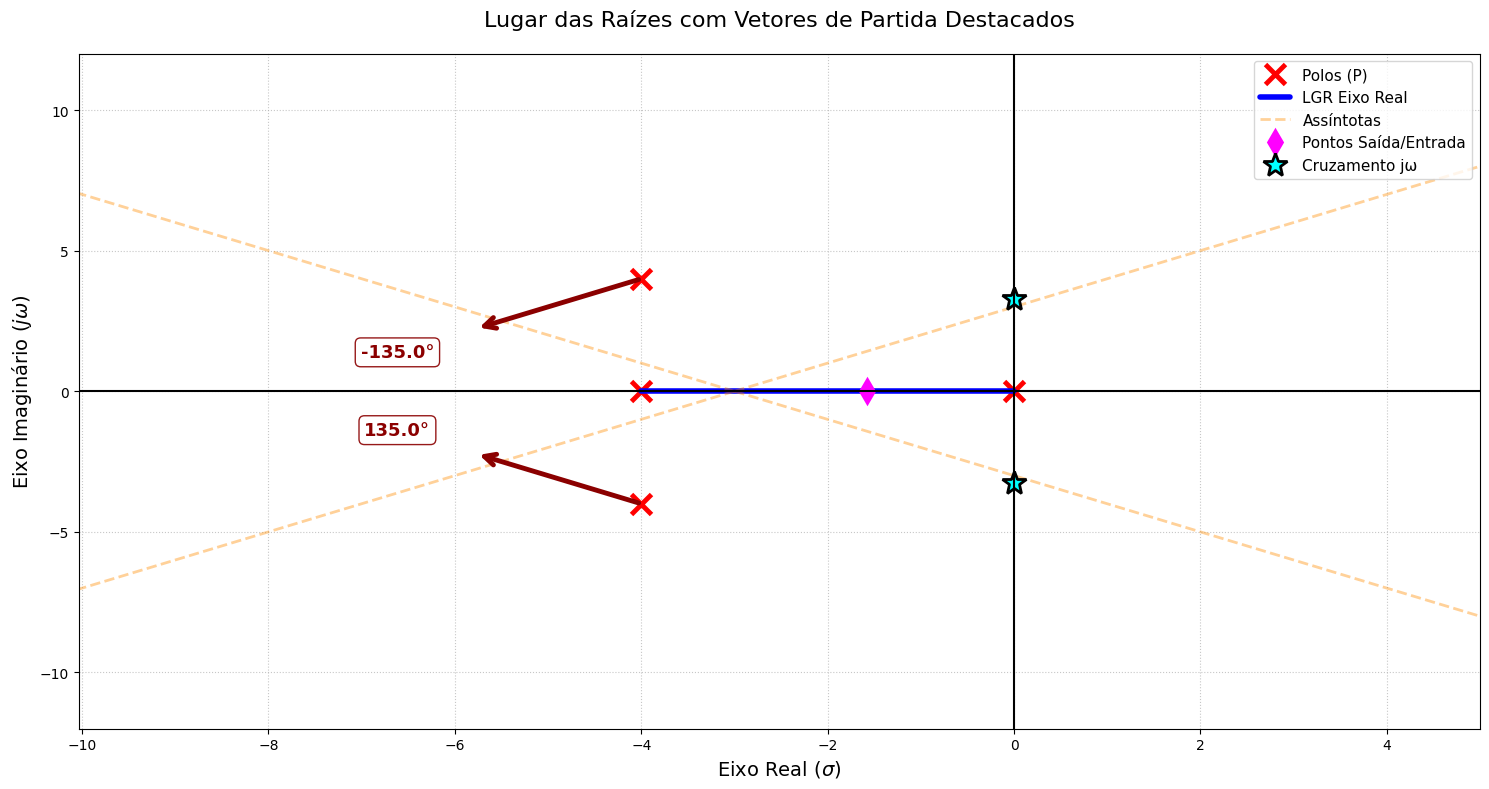

In [140]:
# Célula 8: Passo 10 - Ângulos de Partida e Chegada (COM VETORES DESTACADOS)
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# 1. Identificar polos e zeros complexos (parte imaginária não nula)
tol = 1e-5
complex_poles = [p for p in all_poles if abs(p.imag) > tol]
complex_zeros = [z for z in all_zeros if abs(z.imag) > tol]

departure_angles = {}
arrival_angles = {}

display(Markdown("### Passo 10: Ângulos de Partida e Chegada"))

if not complex_poles and not complex_zeros:
    display(Markdown("**Não há polos ou zeros complexos neste sistema.** Logo, o Passo 10 não se aplica (as raízes já partem/chegam pelo eixo real)."))
else:
    # --- 2. Cálculo dos Ângulos de Partida (Polos Complexos) ---
    if complex_poles:
        display(Markdown("#### Ângulos de Partida ($\theta_d$ - Saída dos polos complexos)"))
        display(Markdown(r"**Fórmula:** $\theta_d = 180^\circ - \sum \theta_i + \sum \phi_j$"))

        for pk in complex_poles:
            # np.angle(A - B) dá o ângulo do vetor que aponta de B para A
            angles_from_other_poles = [np.degrees(np.angle(pk - p)) for p in all_poles if not np.isclose(pk, p)]
            angles_from_zeros = [np.degrees(np.angle(pk - z)) for z in all_zeros]

            sum_theta = sum(angles_from_other_poles)
            sum_phi = sum(angles_from_zeros)

            # Aplica a fórmula e normaliza para o intervalo [-180°, +180°]
            angle_dep = (180.0 - sum_theta + sum_phi) % 360.0
            if angle_dep > 180: angle_dep -= 360

            departure_angles[pk] = angle_dep
            display(Markdown(rf"Para o polo $p = {pk.real:.2f}{pk.imag:+.2f}j$: $\theta_d = {angle_dep:.2f}^\circ$"))

    # --- 3. Cálculo dos Ângulos de Chegada (Zeros Complexos) ---
    # Nota: Para o exemplo atual, esta parte será pulada pois não há zeros complexos.
    if complex_zeros:
        display(Markdown("#### Ângulos de Chegada ($\theta_a$ - Entrada nos zeros complexos)"))
        display(Markdown(r"**Fórmula:** $\theta_a = 180^\circ - \sum \phi_i + \sum \theta_j$"))

        for zk in complex_zeros:
            angles_from_other_zeros = [np.degrees(np.angle(zk - z)) for z in all_zeros if not np.isclose(zk, z)]
            angles_from_poles = [np.degrees(np.angle(zk - p)) for p in all_poles]

            sum_phi_z = sum(angles_from_other_zeros)
            sum_theta_z = sum(angles_from_poles)

            # Aplica a fórmula e normaliza para o intervalo [-180°, +180°]
            angle_arr = (180.0 - sum_phi_z + sum_theta_z) % 360.0
            if angle_arr > 180: angle_arr -= 360

            arrival_angles[zk] = angle_arr
            display(Markdown(rf"Para o zero $z = {zk.real:.2f}{zk.imag:+.2f}j$: $\theta_a = {angle_arr:.2f}^\circ$"))

# --- 4. Plotagem com os Ângulos Indicados Explicitamente ---
plt.figure(figsize=(15, 8)) # Aumentei um pouco a altura para acomodar os textos complexos
ax = plt.gca()

# Re-plotar elementos base
plt.plot(np.real(all_poles), np.imag(all_poles), 'x', markersize=14, color='red', markeredgewidth=3.5, label='Polos (P)')
if all_zeros:
    plt.plot(np.real(all_zeros), np.imag(all_zeros), 'o', markersize=12, color='green', fillstyle='none', markeredgewidth=2.5, label='Zeros (Z)')

for i, (start, end) in enumerate(rl_segments):
    plt.plot([start, end], [0, 0], color='blue', linewidth=4, solid_capstyle='round', label='LGR Eixo Real' if i == 0 else "")

if Na > 0:
    line_length = 40 # Aumentei para visualização
    for i, angle in enumerate(angles_rad):
        dx = line_length * np.cos(angle)
        dy = line_length * np.sin(angle)
        plt.plot([sigma_A, sigma_A + dx], [0, dy], '--', color='darkorange', alpha=0.4, linewidth=2, label='Assíntotas' if i == 0 else "")

if valid_break_points:
    plt.plot(valid_break_points, [0]*len(valid_break_points), 'd', markersize=12, color='magenta', markeredgewidth=2, label='Pontos Saída/Entrada')

if valid_crossings:
    cross_y = [pt.imag for pt in valid_crossings]
    plt.plot([0]*len(valid_crossings), cross_y, '*', markersize=18, color='cyan', markeredgewidth=2, markeredgecolor='black', label='Cruzamento jω')

# --- NOVO: Desenhar Vetores e Rótulos de Texto Destacados ---
arrow_len = 2.5  # Tamanho do vetor indicador aumentado consideravelmente
text_offset = 1.2 # Distância extra para o texto não ficar colado na seta

for pk, angle_deg in departure_angles.items():
    angle_rad = np.radians(angle_deg)
    dx = arrow_len * np.cos(angle_rad)
    dy = arrow_len * np.sin(angle_rad)

    # 1. Desenha a seta vermelha grossa saindo do polo
    plt.annotate('', xy=(pk.real + dx, pk.imag + dy), xytext=(pk.real, pk.imag),
                 arrowprops=dict(arrowstyle="->", color="darkred", lw=3.5, mutation_scale=20))

    # 2. Adiciona o rótulo de texto com o ângulo
    tx = pk.real + (arrow_len + text_offset) * np.cos(angle_rad)
    ty = pk.imag + (arrow_len + text_offset) * np.sin(angle_rad)

    # Pequeno ajuste vertical para não sobrepor se for perto de 0/180 graus
    if abs(np.sin(angle_rad)) < 0.3: ty += 1.0 * np.sign(pk.imag)

    plt.text(tx, ty, f'{angle_deg:.1f}°', color='darkred', fontsize=13, fontweight='bold', ha='center', va='center',
             bbox=dict(facecolor='white', edgecolor='darkred', boxstyle='round,pad=0.3', alpha=0.9))

# (Lógica mantida para zeros complexos caso o sistema mude no futuro)
for zk, angle_deg in arrival_angles.items():
    angle_rad = np.radians(angle_deg)
    dx = arrow_len * np.cos(angle_rad)
    dy = arrow_len * np.sin(angle_rad)
    plt.annotate('', xy=(zk.real, zk.imag), xytext=(zk.real - dx, zk.imag - dy),
                 arrowprops=dict(arrowstyle="->", color="darkgreen", lw=3.5, mutation_scale=20))

    tx = zk.real - (arrow_len + text_offset) * np.cos(angle_rad)
    ty = zk.imag - (arrow_len + text_offset) * np.sin(angle_rad)

    plt.text(tx, ty, f'{angle_deg:.1f}°', color='darkgreen', fontsize=13, fontweight='bold', ha='center', va='center',
             bbox=dict(facecolor='white', edgecolor='darkgreen', boxstyle='round,pad=0.3', alpha=0.9))


# Estilização final
plt.axhline(0, color='black', linewidth=1.5)
plt.axvline(0, color='black', linewidth=1.5)

# Ajuste dinâmico de limites (aumentado para caber as setas e textos novos)
all_x_coords = [p.real for p in all_poles] + [z.real for z in all_zeros]
if Na > 0: all_x_coords.append(sigma_A)
all_x_coords.extend(valid_break_points)
for start, end in rl_segments:
    all_x_coords.extend([start, end])
# Incluir as pontas das setas complexas no cálculo do limite
for pk, angle_deg in departure_angles.items():
    all_x_coords.append(pk.real + (arrow_len + text_offset + 2) * np.cos(np.radians(angle_deg)))

if all_x_coords:
    x_min, x_max = min(all_x_coords), max(all_x_coords)
    x_span = x_max - x_min
    padding_x = x_span * 0.25 if x_span > 0 else 5.0
    plt.xlim(x_min - padding_x, max(x_max + padding_x, 5))

    y_coords = [abs(p.imag) for p in all_poles] + [abs(z.imag) for z in all_zeros]
    if valid_crossings: y_coords.extend([abs(pt.imag) for pt in valid_crossings])
    for pk, angle_deg in departure_angles.items():
        y_coords.append(abs(pk.imag + (arrow_len + text_offset + 2) * np.sin(np.radians(angle_deg))))

    y_limit = max(y_coords) + 8 if y_coords else 8
    plt.ylim(-y_limit, y_limit)

ax.set_aspect('auto')
plt.title('Lugar das Raízes com Vetores de Partida Destacados', fontsize=16, pad=20)
plt.xlabel(r'Eixo Real ($\sigma$)', fontsize=14)
plt.ylabel(r'Eixo Imaginário ($j\omega$)', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.7)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

# Passo 11: Critério de Ang

### Passo 11: Verificação de Ponto no LGR (Critério de Ângulo)

**Ponto de teste:** $s = -1.0 +1.0j$

#### Ângulos partindo dos Polos ($\theta_i$):

Vetor do polo $p_1 = -4.00+0.00j$ até $s$: $\theta_1 = 18.43^\circ$

Vetor do polo $p_2 = 0.00+0.00j$ até $s$: $\theta_2 = 135.00^\circ$

...

**Somatório ($\sum \theta_i$):** $167.47^\circ$

*Não há zeros no sistema, logo $\sum \phi_j = 0^\circ$*

#### Avaliação Final:

Ângulo Resultante = $\sum \theta_i - \sum \phi_j = 167.47^\circ - 0.00^\circ = 167.47^\circ$

**Veredito:** O ângulo $167.47^\circ$ NÃO está dentro da tolerância aceitável ($180^\circ \pm 10.0^\circ$). <br>❌ **O ponto NÃO PERTENCE ao LGR!**

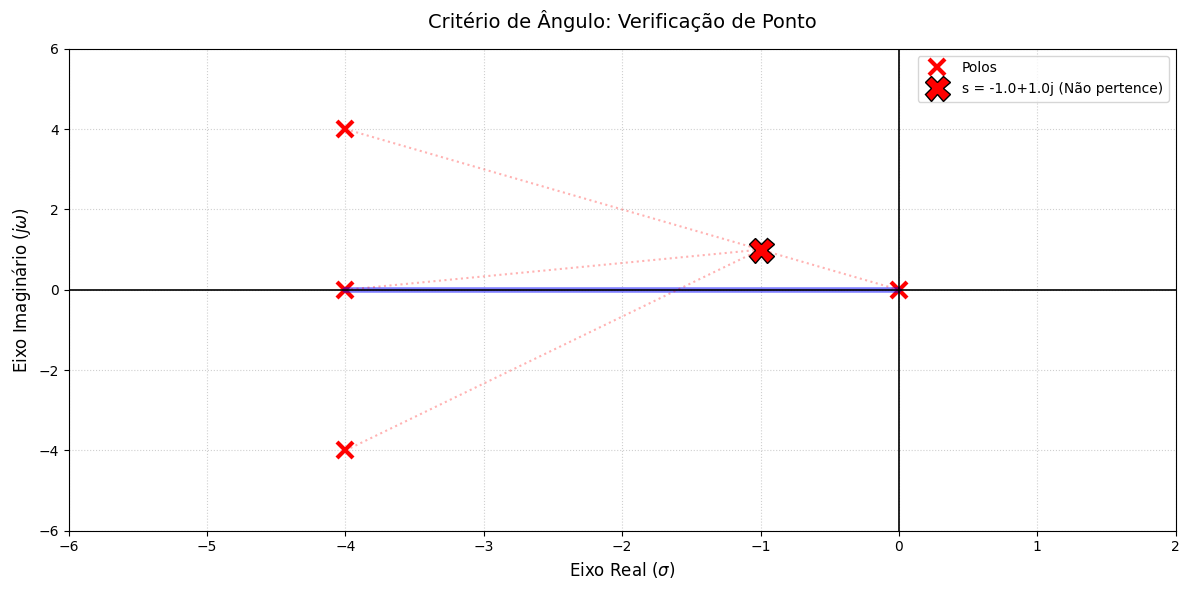

In [142]:
# Célula 9: Passo 11 - Verificação de Pertencimento ao LGR (Critério de Ângulo)
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# ====================================================================
# DEFINA O PONTO DE TESTE AQUI
s_test = complex(-1, 1) # Exemplo: s = -1 + 1j (Mude para testar outros!)
threshold = 10.0        # Tolerância de +- 10 graus
# ====================================================================

display(Markdown("### Passo 11: Verificação de Ponto no LGR (Critério de Ângulo)"))
display(Markdown(rf"**Ponto de teste:** $s = {s_test.real} {s_test.imag:+}j$"))

# 1. Calcular os ângulos (em graus) dos vetores de cada polo até o ponto s_test
theta_poles = [np.degrees(np.angle(s_test - p)) for p in all_poles]

# 2. Calcular os ângulos (em graus) dos vetores de cada zero até o ponto s_test
phi_zeros = [np.degrees(np.angle(s_test - z)) for z in all_zeros]

sum_theta = sum(theta_poles)
sum_phi = sum(phi_zeros)

# 3. Aplicar a fórmula do critério de ângulo: (Soma Thetas) - (Soma Phis)
total_angle = sum_theta - sum_phi

# Normalizar o ângulo para o intervalo [0, 360) para facilitar a comparação
total_angle_norm = total_angle % 360.0

# 4. Verificar se está dentro da janela de 180 +- threshold
is_on_lgr = (180.0 - threshold) <= total_angle_norm <= (180.0 + threshold)

# --- Exibição dos Cálculos Matemáticos ---
display(Markdown(r"#### Ângulos partindo dos Polos ($\theta_i$):"))
for i, p in enumerate(all_poles):
    display(Markdown(rf"Vetor do polo $p_{i+1} = {p.real:.2f}{p.imag:+.2f}j$ até $s$: $\theta_{i+1} = {theta_poles[i]:.2f}^\circ$"))
display(Markdown(rf"**Somatório ($\sum \theta_i$):** ${sum_theta:.2f}^\circ$"))

if all_zeros:
    display(Markdown(r"#### Ângulos partindo dos Zeros ($\phi_j$):"))
    for j, z in enumerate(all_zeros):
        display(Markdown(rf"Vetor do zero $z_{j+1} = {z.real:.2f}{z.imag:+.2f}j$ até $s$: $\phi_{j+1} = {phi_zeros[j]:.2f}^\circ$"))
    display(Markdown(rf"**Somatório ($\sum \phi_j$):** ${sum_phi:.2f}^\circ$"))
else:
    display(Markdown(r"*Não há zeros no sistema, logo $\sum \phi_j = 0^\circ$*"))

display(Markdown("#### Avaliação Final:"))
display(Markdown(rf"Ângulo Resultante = $\sum \theta_i - \sum \phi_j = {sum_theta:.2f}^\circ - {sum_phi:.2f}^\circ = {total_angle:.2f}^\circ$"))

if total_angle < 0 or total_angle >= 360:
    display(Markdown(rf"Normalizando o ângulo (módulo $360^\circ$): ${total_angle_norm:.2f}^\circ$"))

if is_on_lgr:
    display(Markdown(rf"**Veredito:** O ângulo ${total_angle_norm:.2f}^\circ$ está dentro da tolerância aceitável ($180^\circ \pm {threshold}^\circ$). <br>✅ **O ponto PERTENCE ao LGR!**"))
else:
    display(Markdown(rf"**Veredito:** O ângulo ${total_angle_norm:.2f}^\circ$ NÃO está dentro da tolerância aceitável ($180^\circ \pm {threshold}^\circ$). <br>❌ **O ponto NÃO PERTENCE ao LGR!**"))


# --- Plotagem para Visualização do Ponto ---
plt.figure(figsize=(12, 6))
ax = plt.gca()

# Plotar Polos, Zeros e Eixo Real (simplificado para focar no ponto)
plt.plot(np.real(all_poles), np.imag(all_poles), 'x', markersize=12, color='red', markeredgewidth=3, label='Polos')
if all_zeros:
    plt.plot(np.real(all_zeros), np.imag(all_zeros), 'o', markersize=10, color='green', fillstyle='none', markeredgewidth=2, label='Zeros')

for i, (start, end) in enumerate(rl_segments):
    plt.plot([start, end], [0, 0], color='blue', linewidth=4, solid_capstyle='round', alpha=0.5)

# Plotar o ponto de teste
point_color = 'limegreen' if is_on_lgr else 'red'
point_marker = '*' if is_on_lgr else 'X'
point_label = f's = {s_test.real}{s_test.imag:+}j (Pertence)' if is_on_lgr else f's = {s_test.real}{s_test.imag:+}j (Não pertence)'

plt.plot(s_test.real, s_test.imag, point_marker, markersize=18, color=point_color, markeredgecolor='black', label=point_label)

# Desenhar vetores ilustrativos (linha tracejada fina) do polo/zero até o ponto
for p in all_poles:
    plt.plot([p.real, s_test.real], [p.imag, s_test.imag], ':', color='red', alpha=0.3)
for z in all_zeros:
    plt.plot([z.real, s_test.real], [z.imag, s_test.imag], ':', color='green', alpha=0.3)

# Estilização
plt.axhline(0, color='black', linewidth=1.2)
plt.axvline(0, color='black', linewidth=1.2)

# Ajuste dinâmico incluindo o ponto de teste
all_x_coords = [p.real for p in all_poles] + [z.real for z in all_zeros] + [s_test.real]
if all_x_coords:
    x_min, x_max = min(all_x_coords), max(all_x_coords)
    plt.xlim(x_min - 2, x_max + 2)

    y_coords = [abs(p.imag) for p in all_poles] + [abs(z.imag) for z in all_zeros] + [abs(s_test.imag)]
    y_limit = max(y_coords) + 2 if y_coords else 4
    plt.ylim(-y_limit, y_limit)

ax.set_aspect('auto')
plt.title('Critério de Ângulo: Verificação de Ponto', fontsize=14, pad=15)
plt.xlabel(r'Eixo Real ($\sigma$)', fontsize=12)
plt.ylabel(r'Eixo Imaginário ($j\omega$)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Passo 12 : Determinando K

In [143]:
# Célula 10: Passo 12 - Cálculo do Ganho K (Critério de Módulo)
import numpy as np
from IPython.display import display, Markdown

display(Markdown("### Passo 12: Determinar o valor do parâmetro K na raiz (Critério de Módulo)"))

if not is_on_lgr:
    display(Markdown(r"⚠️ **Aviso:** O ponto $s$ definido no passo anterior **não pertence** ao LGR (falhou no critério de ângulo). O valor de $K$ calculado abaixo satisfaz a magnitude, mas as raízes reais do sistema nunca passarão exatamente por este ponto."))

display(Markdown(rf"**Ponto de análise:** $s_i = {s_test.real}{s_test.imag:+}j$"))

display(Markdown(r"**Fórmula do Critério de Módulo:**"))
display(Markdown(r"$$|KP(s)|_{s=s_i} = 1 \implies K = \frac{\prod_{j=1}^{n_p} |s_i - p_j|}{\prod_{k=1}^{n_z} |s_i - z_k|}$$"))

# 1. Calcular as distâncias (módulos) do ponto até cada polo
dist_poles = [np.abs(s_test - p) for p in all_poles]
prod_poles = np.prod(dist_poles) if dist_poles else 1.0

# 2. Calcular as distâncias (módulos) do ponto até cada zero
dist_zeros = [np.abs(s_test - z) for z in all_zeros]
prod_zeros = np.prod(dist_zeros) if dist_zeros else 1.0

# 3. Calcular o Ganho K
K_calculated = prod_poles / prod_zeros

# --- Exibição detalhada dos cálculos ---
display(Markdown(r"#### Distâncias aos Polos ($|s_i - p_j|$):"))
for i, (p, d) in enumerate(zip(all_poles, dist_poles)):
    display(Markdown(rf"Distância até $p_{i+1} = {p.real:.2f}{p.imag:+.2f}j$: **${d:.4f}$**"))
display(Markdown(rf"**Produto das distâncias aos polos:** ${prod_poles:.4f}$"))

if all_zeros:
    display(Markdown(r"#### Distâncias aos Zeros ($|s_i - z_k|$):"))
    for j, (z, d) in enumerate(zip(all_zeros, dist_zeros)):
        display(Markdown(rf"Distância até $z_{j+1} = {z.real:.2f}{z.imag:+.2f}j$: **${d:.4f}$**"))
    display(Markdown(rf"**Produto das distâncias aos zeros:** ${prod_zeros:.4f}$"))
else:
    display(Markdown(r"*Não há zeros no sistema. O denominador é 1.*"))

display(Markdown(r"#### Resultado Final:"))
display(Markdown(rf"$$K = \frac{{{prod_poles:.4f}}}{{{prod_zeros:.4f}}} = {K_calculated:.4f}$$"))

display(Markdown(rf"✅ Para que as raízes do sistema se encontrem no ponto $s = {s_test.real}{s_test.imag:+}j$, o ganho deve ser **$K = {K_calculated:.4f}$**."))

### Passo 12: Determinar o valor do parâmetro K na raiz (Critério de Módulo)

⚠️ **Aviso:** O ponto $s$ definido no passo anterior **não pertence** ao LGR (falhou no critério de ângulo). O valor de $K$ calculado abaixo satisfaz a magnitude, mas as raízes reais do sistema nunca passarão exatamente por este ponto.

**Ponto de análise:** $s_i = -1.0+1.0j$

**Fórmula do Critério de Módulo:**

$$|KP(s)|_{s=s_i} = 1 \implies K = \frac{\prod_{j=1}^{n_p} |s_i - p_j|}{\prod_{k=1}^{n_z} |s_i - z_k|}$$

...

**Produto das distâncias aos polos:** $110.6345$

*Não há zeros no sistema. O denominador é 1.*

#### Resultado Final:

$$K = \frac{110.6345}{1.0000} = 110.6345$$

✅ Para que as raízes do sistema se encontrem no ponto $s = -1.0+1.0j$, o ganho deve ser **$K = 110.6345$**.